In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings
filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Sequential

from tensorflow.keras.optimizers.legacy import Optimizer
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

import pickle
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.regularizers import l2

from time import perf_counter

2025-04-18 06:04:42.844920: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-18 06:04:42.947476: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-18 06:04:42.947589: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-18 06:04:42.948990: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-18 06:04:42.968087: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-18 06:04:42.969927: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [7]:
counts = pd.read_csv('/work/counts_pred.csv')
X = pd.read_csv('/work/preprocessed.csv')
X['No Of Withdrawals'] = StandardScaler().fit_transform(counts)

y = pd.read_csv('/work/target.csv')['Total amount Withdrawn']

d1_x, d2_x, d1_y, d2_y = train_test_split(X, y, test_size=0.35, random_state=42)
d2_train_x, d2_test_x, d2_train_y, d2_test_y = train_test_split(d2_x, d2_y, test_size=0.3, random_state=42)

d1_y_norm = (d1_y - d1_y.mean()) / d1_y.std()
d2_y_norm = (d2_y - d2_y.mean()) / d2_y.std()

# d1_y_norm = (d1_y.max() - d1_y ) / (d1_y.max() - d1_y.min())
# d2_y_norm = (d2_y.max() - d2_y ) / (d2_y.max() - d2_y.min())

# d2_train_y_norm = (d2_train_y.max() - d2_train_y) / (d2_train_y.max() - d2_train_y.min())
# d2_test_y_norm = (d2_test_y.max() - d2_test_y) / (d2_test_y.max() - d2_test_y.min()) 


d2_train_y_norm = (d2_train_y - d2_train_y.mean()) / d2_train_y.std()
d2_test_y_norm = (d2_test_y - d2_test_y.mean()) / d2_test_y.std()


In [8]:
def get_NN_y(D1_features, D1_targets, D2_features, D2_targets):

    # Define NN_y model
    NN_y = Sequential([
        Dense(64, activation='relu', input_shape=(D1_features.shape[1],), kernel_initializer='he_normal'),
        BatchNormalization(),
        Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.3),
        Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.3),
        BatchNormalization(),
        Dense(1, activation='linear')
    ])

    optimizer = AdamW(learning_rate=1e-3, weight_decay=1e-2, clipnorm=1.0)


    # Compile model
    NN_y.compile(optimizer=optimizer, loss='mse', metrics=['mae'], )

    # Train NN_y
    history_y = NN_y.fit(D1_features, D1_targets,validation_data=(D2_features, D2_targets),epochs=200,batch_size=32,verbose=1)

    return NN_y, history_y


In [9]:
t1 = perf_counter()
NN_y, history_y = get_NN_y(d1_x, d1_y_norm, d2_x, d2_y_norm)
t2 = perf_counter()
print(f'NN_y took {t2-t1:.1f} seconds to train')

Epoch 1/200
258/258 [==============================] - 3s 6ms/step - loss: 2.1713 - mae: 0.6662 - val_loss: 1.1731 - val_mae: 0.3027
Epoch 2/200
258/258 [==============================] - 1s 5ms/step - loss: 0.9071 - mae: 0.3814 - val_loss: 0.5404 - val_mae: 0.3136
Epoch 3/200
258/258 [==============================] - 1s 3ms/step - loss: 0.4084 - mae: 0.3213 - val_loss: 0.2927 - val_mae: 0.3128
Epoch 4/200
258/258 [==============================] - 1s 4ms/step - loss: 0.2346 - mae: 0.3006 - val_loss: 0.1954 - val_mae: 0.2979
Epoch 5/200
258/258 [==============================] - 1s 4ms/step - loss: 0.1853 - mae: 0.3020 - val_loss: 0.1364 - val_mae: 0.2613
Epoch 6/200
258/258 [==============================] - 1s 3ms/step - loss: 0.1673 - mae: 0.2976 - val_loss: 0.1147 - val_mae: 0.2339
Epoch 7/200
258/258 [==============================] - 1s 4ms/step - loss: 0.1604 - mae: 0.2972 - val_loss: 0.1133 - val_mae: 0.2429
Epoch 8/200
258/258 [==============================] - 1s 3ms/step - 

In [10]:
NN_y.save('NN_y_amt.keras')
NN_y.save('NN_y_amt.h5')

with open('NN_y_amt', 'wb') as file:

    pickle.dump(NN_y, file)

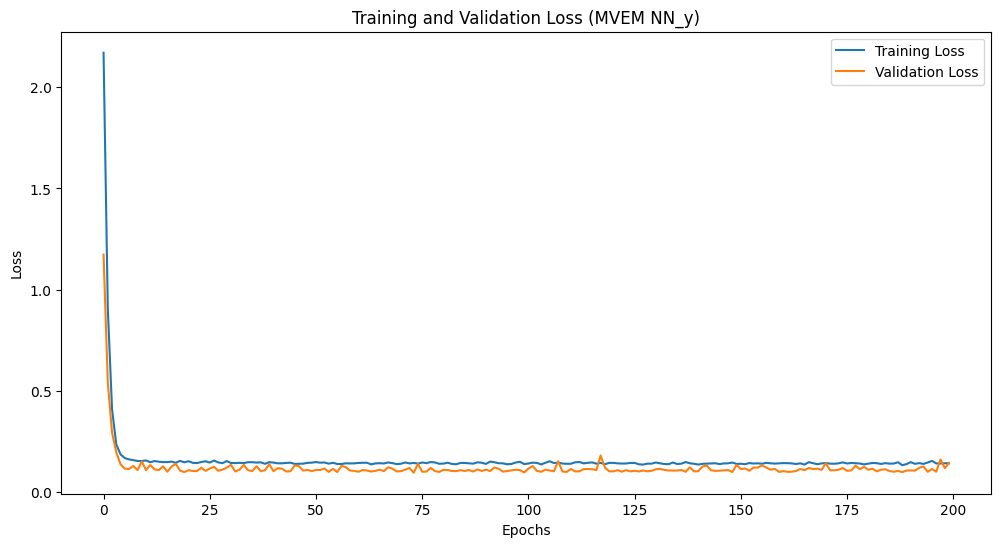

In [11]:
plt.figure(figsize=(12,6))
plt.plot(history_y.history['loss'], label='Training Loss')
plt.plot(history_y.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss (MVEM NN_y)')
plt.show()

In [18]:
# Compute Z-scores for the target values
z_scores = np.abs((d2_y - d2_y.mean()) / d2_y.std())

# Define a threshold to identify outliers
outlier_threshold = 3
weights = np.where(z_scores > outlier_threshold, 0.5, 1.0)  # Assign lower weight to outliers

@keras.utils.register_keras_serializable()
def mve_loss(y_true_combined, y_pred):
    true_targets = y_true_combined[:, 0]
    mean_predictions = y_true_combined[:, 1]

    variance = tf.exp(y_pred) + 1e-10  # Ensure positive variance
    # variance = tf.clip_by_value(tf.exp(y_pred) + 1e-7, 1e-6, 1e3) # Clipped and increased epsilon

    log_variance = tf.math.log(variance)
    squared_error = (true_targets - mean_predictions) ** 2 / variance

    # Regularization term to penalize large variances
    lambda_reg = 1e-3
    regularization = lambda_reg * variance

    loss = (log_variance + squared_error + regularization)

    return tf.reduce_mean(loss)


In [21]:
def get_NN_sigma(D2_train_features, D2_train_targets_combined, D2_val_features, D2_val_targets_normalized):

    # Define NN_sigma model
    NN_sigma = Sequential([

        Dense(64, activation='relu', input_shape=(D2_train_features.shape[1],), kernel_initializer='he_normal'),
        BatchNormalization(),
        Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.3),
        Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.3),
        BatchNormalization(),
        Dense(1, activation='exponential')
    ])


    # Compile NN_sigma with the updated loss function

    optimizer = AdamW(learning_rate=1e-3, weight_decay=1e-4, clipnorm=1.0)
    NN_sigma.compile(optimizer=optimizer, loss=mve_loss, metrics=['mae'])


    # Train NN_sigma
    history_sigma = NN_sigma.fit(
        D2_train_features,
        D2_train_targets_combined,  # Combined targets (true + mean_predictions)
        validation_data=(D2_val_features, np.column_stack((D2_val_targets_normalized, NN_y.predict(D2_val_features)))),
        epochs=200,
        batch_size=32,
        verbose=1,
      )

    return NN_sigma, history_sigma


In [24]:
# Precompute predictions from NN_y
mean_predictions = NN_y.predict(d2_train_x)

# Concatenate true targets and precomputed mean predictions
d2_train_y_combined = np.column_stack((d2_train_y_norm, mean_predictions))


98/98 [==============================] - 0s 2ms/step


In [27]:
NN_sigma, history_sigma = get_NN_sigma(d2_train_x, d2_train_y_combined, d2_test_x, d2_test_y_norm)

42/42 [==============================] - 0s 3ms/step
Epoch 1/200
98/98 [==============================] - 3s 10ms/step - loss: 955126143702543719121027072.0000 - mae: 1.7481 - val_loss: 1.9860 - val_mae: 0.9777
Epoch 2/200
98/98 [==============================] - 1s 5ms/step - loss: 1.8640 - mae: 0.9764 - val_loss: 1.2525 - val_mae: 0.8807
Epoch 3/200
98/98 [==============================] - 0s 5ms/step - loss: 24.2875 - mae: 0.8905 - val_loss: 0.8358 - val_mae: 0.8640
Epoch 4/200
98/98 [==============================] - 1s 6ms/step - loss: 0.7202 - mae: 0.8616 - val_loss: 0.5830 - val_mae: 0.8660
Epoch 5/200
98/98 [==============================] - 1s 7ms/step - loss: 0.4906 - mae: 0.8547 - val_loss: 0.4049 - val_mae: 0.8620
Epoch 6/200
98/98 [==============================] - 1s 7ms/step - loss: 0.3489 - mae: 0.8544 - val_loss: 0.2971 - val_mae: 0.8611
Epoch 7/200
98/98 [==============================] - 0s 4ms/step - loss: 0.2601 - mae: 0.8523 - val_loss: 0.2291 - val_mae: 0.8599
Ep

In [30]:
NN_sigma.save('NN_sigma_amt.keras')
NN_sigma.save('NN_sigma_amt.h5')

with open('NN_sigma_amt', 'wb') as file:

    pickle.dump(NN_sigma, file)


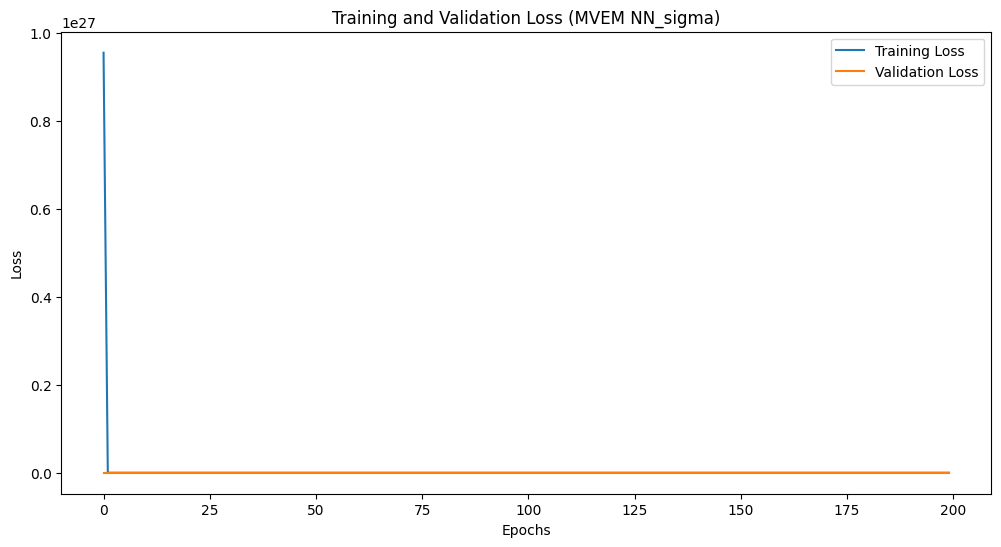

In [33]:
plt.figure(figsize=(12,6))
plt.plot(history_sigma.history['loss'], label='Training Loss')
plt.plot(history_sigma.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss (MVEM NN_sigma)')
plt.show()

In [36]:
# Predict the mean (from NN_y) and variance (from NN_sigma)
mean_predictions = NN_y.predict(d2_x).flatten()
variance_predictions = np.exp(NN_sigma.predict(d2_x)).flatten()  # Apply exp to get positive variance

# Denormalize mean predictions
# mean_predictions_denormalized = mean_predictions * (d1_y.max() - d1_y.min()) + d1_y.min()
mean_predictions_denormalized = (mean_predictions * d1_y.std() + d1_y.mean())

# Denormalize variance predictions
# variance_predictions_denormalized = variance_predictions * (d1_y.max() - d1_y.min()) ** 2 # Variance scales with the square of std
variance_predictions_denormalized = variance_predictions * d1_y.std() ** 2 # Variance scales with the square of std


139/139 [==============================] - 0s 2ms/step


In [319]:
import scipy.stats

# Set confidence level
confidence_level = 0.55
z_score = scipy.stats.norm.ppf((1 + confidence_level) / 2)

# Compute upper and lower bounds of the prediction intervals
lb_amt = mean_predictions_denormalized - z_score * np.sqrt(variance_predictions_denormalized)
ub_amt = mean_predictions_denormalized + z_score * np.sqrt(variance_predictions_denormalized)


In [322]:

minimum = np.quantile(np.abs(lb_amt), 0.01)
# minimum = np.min(np.abs(lb_amt))
lb_amt = np.clip(lb_amt, a_min=minimum, a_max=None) 

lb_amt = lb_amt.flatten().astype('int')
ub_amt = ub_amt.flatten().astype('int')


In [325]:
below_ub = (ub_amt >= d2_y).sum() / len(d2_y)
print('Points Below Upper Bound:', below_ub)

below_lb = (d2_y <= lb_amt).sum() / len(d2_y)
print('Points Below Lower Bound:', below_lb)

Points Below Upper Bound: 0.9722785665990534
Points Below Lower Bound: 0.021185485688528283


In [328]:
def compute_picp(y_lower, y_upper, y_true):
    return np.mean(np.logical_and(y_true >= y_lower, y_true <= y_upper))

def compute_pinrw(y_lower, y_upper, y_true):
    R = np.max(y_true) - np.min(y_true)
    width = np.sqrt(np.mean((y_upper - y_lower) ** 2))
    return width / R

def compute_pinrw(y_lower, y_upper, y_true):
    R = np.max(y_true) - np.min(y_true)
    width = np.sqrt(np.mean((y_upper - y_lower) ** 2))
    return width / R

def cwc_loss_numpy(y_lower, y_upper, y_true, gamma=50, eta=50, mu=0.95):
    picp = compute_picp(y_lower, y_upper, y_true)
    pinrw = compute_pinrw(y_lower, y_upper, y_true)
    penalty = np.exp(eta * (mu - picp))
    cwc = pinrw * (1 + gamma * penalty)
    mpiw = np.mean(y_upper - y_lower)

    return cwc, picp, mpiw, pinrw

In [331]:
cwc, picp, mpiw, pinrw = cwc_loss_numpy(lb_amt, ub_amt, d2_y, gamma=50, eta=50, mu=0.95)
outcome = (d2_y >= lb_amt) & (d2_y <= ub_amt)


result = pd.DataFrame({'Original': np.array(d2_y).flatten(), 'Predicted': mean_predictions_denormalized.flatten(),
                        'Lower Bound': lb_amt.flatten(), 'Upper Bound': ub_amt.flatten(),
                      })

outcome = (result['Original'] > result['Lower Bound']) & (result['Original'] < result['Upper Bound'])

result.to_csv(f'Results_MVEM_amt.csv', index=False)


In [332]:
print('PICP: ', picp)
print('PINRW: ', pinrw)
print('CWC: ', cwc)
print('MPIW: ', mpiw)

PICP:  0.9510930809105251
PINRW:  0.2809037772466301
CWC:  13.57906619872715
MPIW:  337157.53797611


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=6c5dcd7e-ee44-459a-9dd6-5c39b2404cb3' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>